# Panda power three bus problem.

In [ ]:
import pandapower as pp
import numpy as np





In [13]:
# Create empty net
# https://pandapower.readthedocs.io/en/stable/elements/empty_network.html

net = pp.create_empty_network() 

In [14]:
# Inputs
P = 300e-6  # power of the source in Mega Watts. Pandapower works in MW
pf =  0.95  # power factor (lagging)
Number_of_homes = 6

VSlack = 0.132 # slack bus voltage in kV

VBase = 0.120 # base voltage in kV
SBase = P*Number_of_homes


R =  0.37# line resistance in Ohms
X = 0.37 # line reactance in Ohms

XR = 1 # X/R ratio 

# Calculations
V0 =  VSlack / VBase # per unit voltage at slack bus

Ph =  P # power of the home in MW

Qh =  Ph * np.tan(np.arccos(pf)) # reactive power of the home


In [15]:
# Create 7 buses, b1,b2,b3...b7
# https://pandapower.readthedocs.io/en/stable/elements/bus.html
V_nom_kV = VSlack  # nominal voltage in kV

b1 = pp.create_bus(net, vn_kv=V_nom_kV,  name="Bus 1")
b2 = pp.create_bus(net, vn_kv=V_nom_kV,  name="Bus 2")
b3 = pp.create_bus(net, vn_kv=V_nom_kV,  name="Bus 3")
b4 = pp.create_bus(net, vn_kv=V_nom_kV,  name="Bus 4")
b5 = pp.create_bus(net, vn_kv=V_nom_kV,  name="Bus 5")
b6 = pp.create_bus(net, vn_kv=V_nom_kV,  name="Bus 6")
b7 = pp.create_bus(net, vn_kv=V_nom_kV,  name="Bus 7")


net.bus

,name,vn_kv,type,zone,in_service,geo
0,Bus 1,0.132,b,None,True,None
1,Bus 2,0.132,b,None,True,None
2,Bus 3,0.132,b,None,True,None
3,Bus 4,0.132,b,None,True,None
4,Bus 5,0.132,b,None,True,None
5,Bus 6,0.132,b,None,True,None
6,Bus 7,0.132,b,None,True,None


In [16]:
###### create bus elements

pp.create_ext_grid(net, bus=b1, vm_pu=1, name="Swing bus") # Bus 1 is the slack bus
pp.create_load(net, bus=b2, p_mw=Ph, q_mvar=Qh, name="Home 1") # From here, we have the loads at each home
pp.create_load(net, bus=b3, p_mw=Ph, q_mvar=Qh, name="Home 2")
pp.create_load(net, bus=b4, p_mw=Ph, q_mvar=Qh, name="Home 3")
pp.create_load(net, bus=b5, p_mw=Ph, q_mvar=Qh, name="Home 4")
pp.create_load(net, bus=b6, p_mw=Ph, q_mvar=Qh, name="Home 5")
pp.create_load(net, bus=b7, p_mw=Ph, q_mvar=Qh, name="Home 6")
# Display the bus table
net.bus

,name,vn_kv,type,zone,in_service,geo
0,Bus 1,0.132,b,None,True,None
1,Bus 2,0.132,b,None,True,None
2,Bus 3,0.132,b,None,True,None
3,Bus 4,0.132,b,None,True,None
4,Bus 5,0.132,b,None,True,None
5,Bus 6,0.132,b,None,True,None
6,Bus 7,0.132,b,None,True,None


In [17]:
## Create lines
pp.create_line_from_parameters(net,from_bus=b1, to_bus=b2,length_km=1, r_ohm_per_km = 0.37, x_ohm_per_km = 0.37, c_nf_per_km = 1e-9, max_i_ka=0.0025)
# Line 2-3
pp.create_line_from_parameters(net,from_bus=b2, to_bus=b3,length_km=1, r_ohm_per_km = 0.37, x_ohm_per_km = 0.37, c_nf_per_km = 1e-9, max_i_ka=0.0025)
# Line 3-4 
pp.create_line_from_parameters(net,from_bus=b3, to_bus=b4,length_km=1, r_ohm_per_km = 0.37, x_ohm_per_km = 0.37, c_nf_per_km = 1e-9, max_i_ka=0.0025)

#Line 4-5
pp.create_line_from_parameters(net,from_bus=b4, to_bus=b5,length_km=1, r_ohm_per_km = 0.37, x_ohm_per_km = 0.37, c_nf_per_km = 1e-9, max_i_ka=0.0025)

# Line 5-6
pp.create_line_from_parameters(net,from_bus=b5, to_bus=b6,length_km=1, r_ohm_per_km = 0.37, x_ohm_per_km = 0.37, c_nf_per_km = 1e-9, max_i_ka=0.0025)

# Line 6-7
pp.create_line_from_parameters(net,from_bus=b6, to_bus=b7,length_km=1, r_ohm_per_km = 0.37, x_ohm_per_km = 0.37, c_nf_per_km = 1e-9, max_i_ka=0.0025)

net.line

,name,std_type,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,g_us_per_km,max_i_ka,df,parallel,type,in_service,geo
0,None,None,0,1,1.0,0.37,0.37,1.000000e-09,0.0,0.0025,1.0,1,None,True,None
1,None,None,1,2,1.0,0.37,0.37,1.000000e-09,0.0,0.0025,1.0,1,None,True,None
2,None,None,2,3,1.0,0.37,0.37,1.000000e-09,0.0,0.0025,1.0,1,None,True,None
3,None,None,3,4,1.0,0.37,0.37,1.000000e-09,0.0,0.0025,1.0,1,None,True,None
4,None,None,4,5,1.0,0.37,0.37,1.000000e-09,0.0,0.0025,1.0,1,None,True,None
5,None,None,5,6,1.0,0.37,0.37,1.000000e-09,0.0,0.0025,1.0,1,None,True,None


In [7]:
net.line

,name,std_type,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,g_us_per_km,max_i_ka,df,parallel,type,in_service,geo
0,None,None,0,1,1.0,0.37,0.37,1.000000e-09,0.0,1000.0,1.0,1,None,True,None
1,None,None,1,2,1.0,0.37,0.37,1.000000e-09,0.0,1000.0,1.0,1,None,True,None
2,None,None,2,3,1.0,0.37,0.37,1.000000e-09,0.0,1000.0,1.0,1,None,True,None
3,None,None,3,4,1.0,0.37,0.37,1.000000e-09,0.0,1000.0,1.0,1,None,True,None
4,None,None,4,5,1.0,0.37,0.37,1.000000e-09,0.0,1000.0,1.0,1,None,True,None
5,None,None,5,6,1.0,0.37,0.37,1.000000e-09,0.0,1000.0,1.0,1,None,True,None


In [18]:
# Do a power flow
# https://pandapower.readthedocs.io/en/stable/powerflow/ac.html

pp.runpp(net, algorithm='gs')
print("Power Flow Results", net.res_line)

Power Flow Results    p_from_mw  q_from_mvar   p_to_mw  q_to_mvar     pl_mw   ql_mvar  i_from_ka  \
0   0.002089     0.000880 -0.001980  -0.000771  0.000109  0.000109   0.009913   
1   0.001680     0.000673 -0.001600  -0.000593  0.000079  0.000079   0.008442   
2   0.001300     0.000495 -0.001248  -0.000442  0.000053  0.000053   0.006882   
3   0.000948     0.000344 -0.000917  -0.000313  0.000030  0.000030   0.005241   
4   0.000617     0.000215 -0.000604  -0.000201  0.000014  0.000014   0.003534   
5   0.000304     0.000102 -0.000300  -0.000099  0.000004  0.000004   0.001779   

    i_to_ka      i_ka  vm_from_pu  va_from_degree  vm_to_pu  va_to_degree  \
0  0.009913  0.009913    1.000000        0.000000  0.937308     -1.568709   
1  0.008442  0.008442    0.937308       -1.568709  0.884316     -3.046958   
2  0.006882  0.006882    0.884316       -3.046958  0.841429     -4.364281   
3  0.005241  0.005241    0.841429       -4.364281  0.808979     -5.444251   
4  0.003534  0.003534    0.8

In [19]:
# Save the network to a json file
# https://pandapower.readthedocs.io/en/stable/file_io.html

pp.to_json(net,"ThreeBus.json")

In [20]:
# View results on the busses
net.res_bus

,vm_pu,va_degree,p_mw,q_mvar
0,1.000000,0.000000,-0.002089,-0.000880
1,0.937308,-1.568709,0.000300,0.000099
2,0.884316,-3.046958,0.000300,0.000099
3,0.841429,-4.364281,0.000300,0.000099
4,0.808979,-5.444251,0.000300,0.000099
5,0.787212,-6.213797,0.000300,0.000099
6,0.776289,-6.614768,0.000300,0.000099


In [21]:
# View results on the lines
net.res_line

,p_from_mw,q_from_mvar,p_to_mw,q_to_mvar,pl_mw,ql_mvar,i_from_ka,i_to_ka,i_ka,vm_from_pu,va_from_degree,vm_to_pu,va_to_degree,loading_percent
0,0.002089,0.000880,-0.001980,-0.000771,0.000109,0.000109,0.009913,0.009913,0.009913,1.000000,0.000000,0.937308,-1.568709,396.534057
1,0.001680,0.000673,-0.001600,-0.000593,0.000079,0.000079,0.008442,0.008442,0.008442,0.937308,-1.568709,0.884316,-3.046958,337.691802
2,0.001300,0.000495,-0.001248,-0.000442,0.000053,0.000053,0.006882,0.006882,0.006882,0.884316,-3.046958,0.841429,-4.364281,275.271198
3,0.000948,0.000344,-0.000917,-0.000313,0.000030,0.000030,0.005241,0.005241,0.005241,0.841429,-4.364281,0.808979,-5.444251,209.635555
4,0.000617,0.000215,-0.000604,-0.000201,0.000014,0.000014,0.003534,0.003534,0.003534,0.808979,-5.444251,0.787212,-6.213797,141.350018
5,0.000304,0.000102,-0.000300,-0.000099,0.000004,0.000004,0.001779,0.001779,0.001779,0.787212,-6.213797,0.776289,-6.614768,71.170391


No or insufficient geodata available --> Creating artificial coordinates. This may take some time


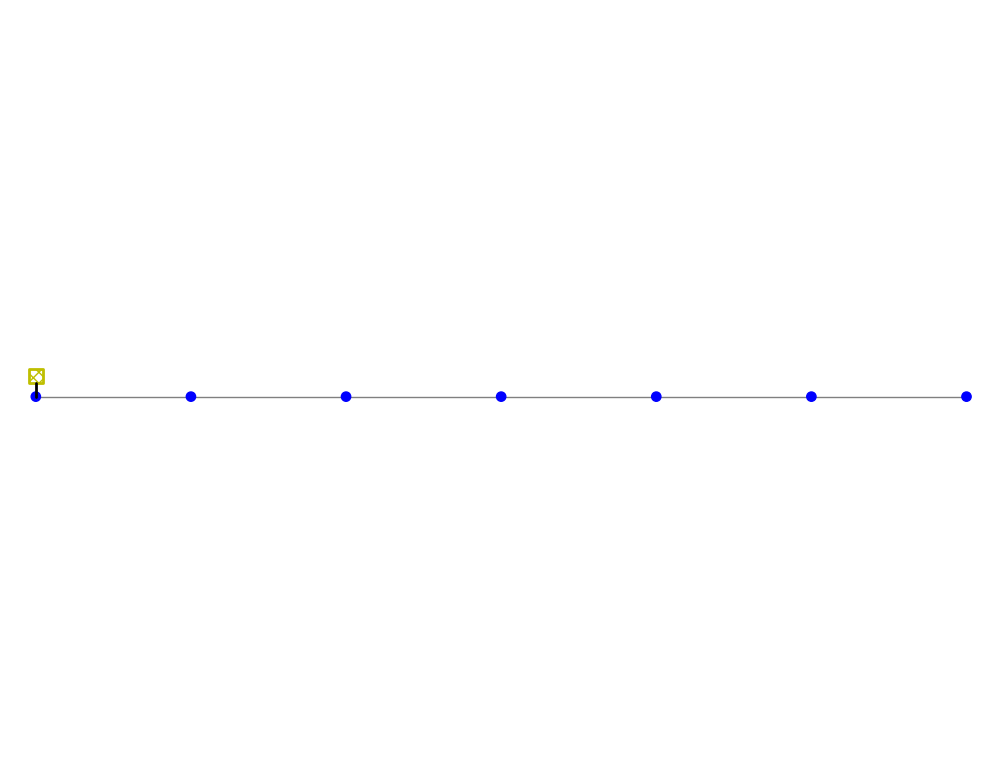

<Axes: >

In [22]:
from pandapower import plotting
from pandapower.plotting import simple_plot
simple_plot(net)

In [44]:
# use collections to plot a colourmap showing line loadings

import matplotlib.pyplot as plt
from matplotlib import colors as color
import pandapower as pp
import pandapower.plotting as plot
%matplotlib inline


sizes = plot.get_collection_sizes(net)

lc = plot.create_line_collection(net, net.line.index, color=color.blue, zorder=1) #create lines
bc = plot.create_bus_collection(net, net.bus.index, size=sizes['bus'], color=color.colors[0], zorder=2) #create buses
plot.draw_collections([lc, bc], figsize=(8,6)) # plot lines and buses

AttributeError: module 'matplotlib.colors' has no attribute 'blue'

<Axes: >

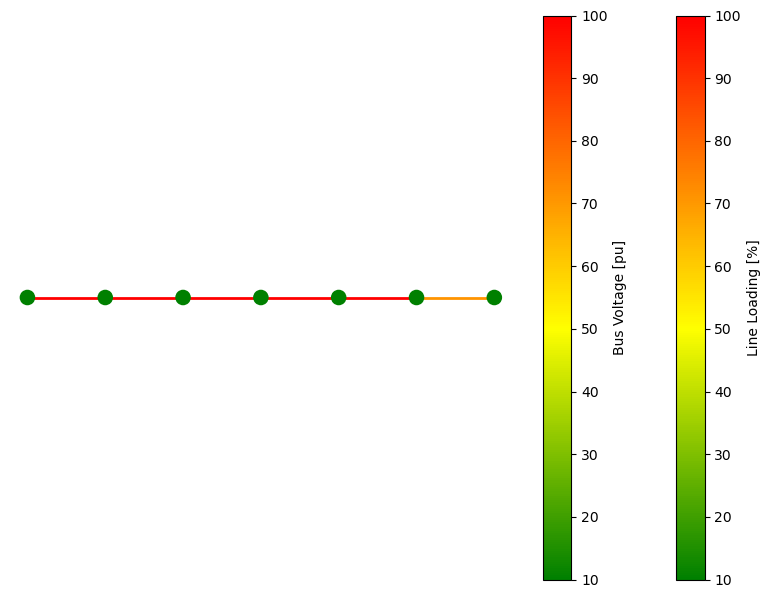

In [ ]:
import pandapower as pp
import pandapower.plotting as plot
%matplotlib inline


pp.runpp(net)
cmap_list=[(10, "green"), (50, "yellow"), (100, "red")] # line loading in %  
cmap, norm = plot.cmap_continuous(cmap_list) # create colormap and normalization

lc = plot.create_line_collection(net, net.line.index, zorder=1, cmap=cmap, norm=norm, linewidths=2) # create lines  
bc = plot.create_bus_collection(net, net.bus.index, size=0.1, zorder=2, cmap=cmap, norm=norm) # create buses
plot.draw_collections([lc, bc], figsize=(8,6))